# 02 _ Baseline Models

Train all models with default hyperparameters to establish baselines.
- Random Forest (scikit-learn)
- MLP (PyTorch)
- GRU (PyTorch)
- LSTM (PyTorch)

## Load Data

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve,
)

DATA_DIR = Path("../data")
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [4]:
# Load dataset and config from notebook 01
config = json.loads((DATA_DIR / "config.json").read_text())
selected_features = config["selected_features"]

df = pd.read_csv(DATA_DIR / "df.csv")
# recreate target
df["t_win"] = df.round_winner.astype("category").cat.codes

X = df[selected_features]
y = df["t_win"]

print(f"Features: {len(selected_features)}, Samples: {len(df)}")

Features: 20, Samples: 122410


In [6]:
# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# validation split from training data (for PyTorch early stopping) from youtube tutorial
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train.values, test_size=0.15, random_state=42
)

print(f"Train: {X_tr.shape}, Val: {X_val.shape}, Test: {X_test_scaled.shape}")

Train: (83238, 20), Val: (14690, 20), Test: (24482, 20)


In [9]:
# pytorch tensors
X_tr_t = torch.FloatTensor(X_tr).to(device)
y_tr_t = torch.FloatTensor(y_tr).to(device)
X_val_t = torch.FloatTensor(X_val).to(device)
y_val_t = torch.FloatTensor(y_val).to(device)
X_test_t = torch.FloatTensor(X_test_scaled).to(device)
y_test_t = torch.FloatTensor(y_test.values).to(device)

train_dataset = TensorDataset(X_tr_t, y_tr_t)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True) # dont get this yet

n_features = X_tr.shape[1]
print(f"Input features: {n_features}")

Input features: 20


## Training Helpers

In [ ]:
def train_pytorch(model, train_loader, X_val_t, y_val_t, epochs=50, patience=7, lr=1e-3):
    """Train a PyTorch model with early stopping. Returns training history. Also from youtube tutorial"""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss() # need to do more research on this
    best_val_loss = float("inf")
    patience_counter = 0
    best_state = None
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs): # from yt vid
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            optimizer.step() # 3blue1brown vid
            epoch_loss += loss.item()

        model.eval()
        with torch.no_grad(): # early stop from yt vid + docs
            val_pred = model(X_val_t)
            val_loss = criterion(val_pred, y_val_t).item()
            val_acc = ((val_pred > 0.5).float() == y_val_t).float().mean().item()

        avg_loss = epoch_loss / len(train_loader)
        history["train_loss"].append(avg_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:3d}/{epochs} — train_loss: {avg_loss:.4f}  val_loss: {val_loss:.4f}  val_acc: {val_acc:.4f}")

        if val_loss < best_val_loss: # save lowst from docs
            best_val_loss = val_loss
            patience_counter = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)
    return history


def evaluate_pytorch(model, X_test_t, y_test_t):
    """Evaluate a PyTorch model. Returns (accuracy, probabilities)."""
    model.eval()
    with torch.no_grad():
        probs = model(X_test_t).cpu().numpy()
        preds = (probs > 0.5).astype(int)
        acc = accuracy_score(y_test_t.cpu().numpy(), preds)
    return acc, probs

## Model 1: Random Forest

In [11]:
# from github project
rf = RandomForestClassifier(n_jobs=-1, random_state=42)
rf.fit(X_train_scaled, y_train)

rf_acc = rf.score(X_test_scaled, y_test)
rf_probs = rf.predict_proba(X_test_scaled)[:, 1]
print(f"Random Forest Accuracy: {rf_acc:.4f}")

Random Forest Accuracy: 0.8288


## Model 2: MLP

In [12]:
class MLP(nn.Module):
    def __init__(self, n_features, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden // 2, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


mlp = MLP(n_features).to(device)
print(mlp)
print(f"Parameters: {sum(p.numel() for p in mlp.parameters()):,}\n")

mlp_history = train_pytorch(mlp, train_loader, X_val_t, y_val_t)
mlp_acc, mlp_probs = evaluate_pytorch(mlp, X_test_t, y_test_t)
print(f"\nMLP Accuracy: {mlp_acc:.4f}")

MLP(
  (net): Sequential(
    (0): Linear(in_features=20, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
    (7): Sigmoid()
  )
)
Parameters: 11,009

  Epoch   1/50 — train_loss: 0.5081  val_loss: 0.4779  val_acc: 0.7491
  Epoch  10/50 — train_loss: 0.4676  val_loss: 0.4660  val_acc: 0.7500
  Epoch  20/50 — train_loss: 0.4620  val_loss: 0.4634  val_acc: 0.7530
  Epoch  30/50 — train_loss: 0.4580  val_loss: 0.4617  val_acc: 0.7551
  Epoch  40/50 — train_loss: 0.4545  val_loss: 0.4626  val_acc: 0.7543
  Early stopping at epoch 42

MLP Accuracy: 0.7551


## Model 3: GRU

Note -> GRU needs sequential data and the dataset is per round snapshots.
I treat each sample as a sequence of length 1 and will fix lator to have a sequence of changes or something
it colould do a lot better if we had sequences

In [13]:
class GRUModel(nn.Module): # from yt vid 3 link in obs
    def __init__(self, n_features, hidden=64, num_layers=1):
        super().__init__()
        self.gru = nn.GRU(n_features, hidden, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        # x shape: (batch, features) -> (batch, 1, features) for GRU
        x = x.unsqueeze(1)
        out, _ = self.gru(x)
        # Take last timestep
        out = out[:, -1, :]
        return torch.sigmoid(self.fc(out)).squeeze(-1)


gru = GRUModel(n_features).to(device)
print(gru)
print(f"Parameters: {sum(p.numel() for p in gru.parameters()):,}\n")

gru_history = train_pytorch(gru, train_loader, X_val_t, y_val_t)
gru_acc, gru_probs = evaluate_pytorch(gru, X_test_t, y_test_t)
print(f"\nGRU Accuracy: {gru_acc:.4f}")

GRUModel(
  (gru): GRU(20, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
Parameters: 16,577

  Epoch   1/50 — train_loss: 0.5200  val_loss: 0.4841  val_acc: 0.7445
  Epoch  10/50 — train_loss: 0.4689  val_loss: 0.4698  val_acc: 0.7515
  Epoch  20/50 — train_loss: 0.4636  val_loss: 0.4665  val_acc: 0.7484
  Epoch  30/50 — train_loss: 0.4611  val_loss: 0.4662  val_acc: 0.7494
  Epoch  40/50 — train_loss: 0.4584  val_loss: 0.4658  val_acc: 0.7511
  Early stopping at epoch 46

GRU Accuracy: 0.7505


## Model 4: LSTM

Same issue as GRU. sequence length of 1 means the recurrent structure isn't
super being leveraged. will fix when i fix gru

In [14]:
class LSTMModel(nn.Module):# from yt vid 4 link in obs
    def __init__(self, n_features, hidden=64, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        x = x.unsqueeze(1)
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return torch.sigmoid(self.fc(out)).squeeze(-1)


lstm = LSTMModel(n_features).to(device)
print(lstm)
print(f"Parameters: {sum(p.numel() for p in lstm.parameters()):,}\n")

lstm_history = train_pytorch(lstm, train_loader, X_val_t, y_val_t)
lstm_acc, lstm_probs = evaluate_pytorch(lstm, X_test_t, y_test_t)
print(f"\nLSTM Accuracy: {lstm_acc:.4f}")

LSTMModel(
  (lstm): LSTM(20, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
Parameters: 22,081

  Epoch   1/50 — train_loss: 0.5243  val_loss: 0.4850  val_acc: 0.7428
  Epoch  10/50 — train_loss: 0.4668  val_loss: 0.4688  val_acc: 0.7498
  Epoch  20/50 — train_loss: 0.4612  val_loss: 0.4659  val_acc: 0.7510
  Epoch  30/50 — train_loss: 0.4581  val_loss: 0.4639  val_acc: 0.7537
  Early stopping at epoch 36

LSTM Accuracy: 0.7512


## Baseline Results

In [15]:
results = {
    "Random Forest": {"acc": rf_acc, "probs": rf_probs, "history": None},
    "MLP": {"acc": mlp_acc, "probs": mlp_probs, "history": mlp_history},
    "GRU": {"acc": gru_acc, "probs": gru_probs, "history": gru_history},
    "LSTM": {"acc": lstm_acc, "probs": lstm_probs, "history": lstm_history},
}

print("=" * 40)
print(f"{'Model':<20} {'Accuracy':>10}")
print("=" * 40)
for name, r in sorted(results.items(), key=lambda x: x[1]["acc"], reverse=True):
    print(f"{name:<20} {r['acc']:>10.4f}")
print("=" * 40)

Model                  Accuracy
Random Forest            0.8288
MLP                      0.7551
LSTM                     0.7512
GRU                      0.7505


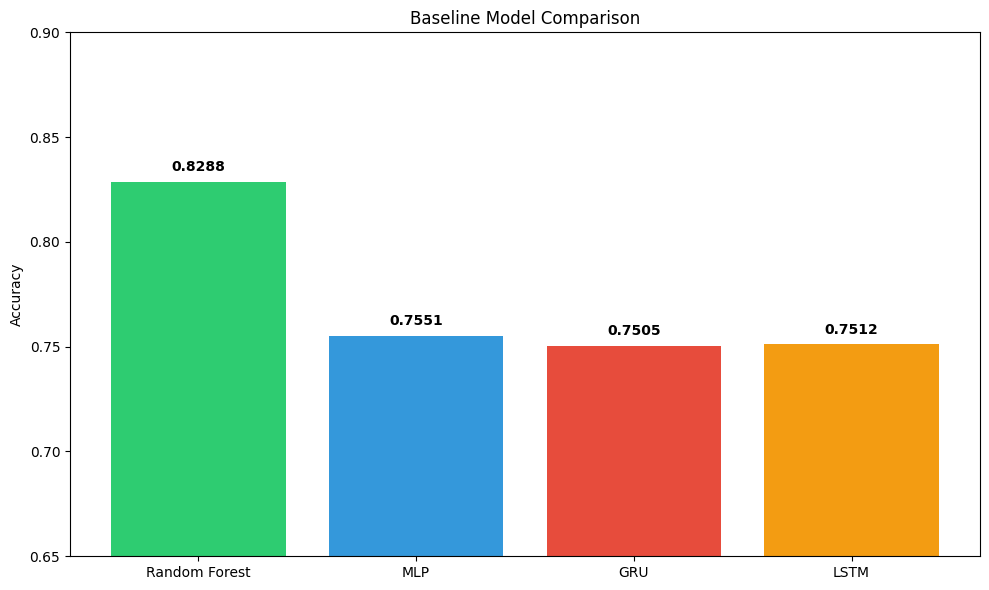

In [16]:
# Accuracy bar chart
fig, ax = plt.subplots(figsize=(10, 6))
names = list(results.keys())
accs = [results[n]["acc"] for n in names]
colors = ["#2ecc71", "#3498db", "#e74c3c", "#f39c12"]
bars = ax.bar(names, accs, color=colors)
ax.set_ylim(0.65, 0.90)
ax.set_ylabel("Accuracy")
ax.set_title("Baseline Model Comparison")
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{acc:.4f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

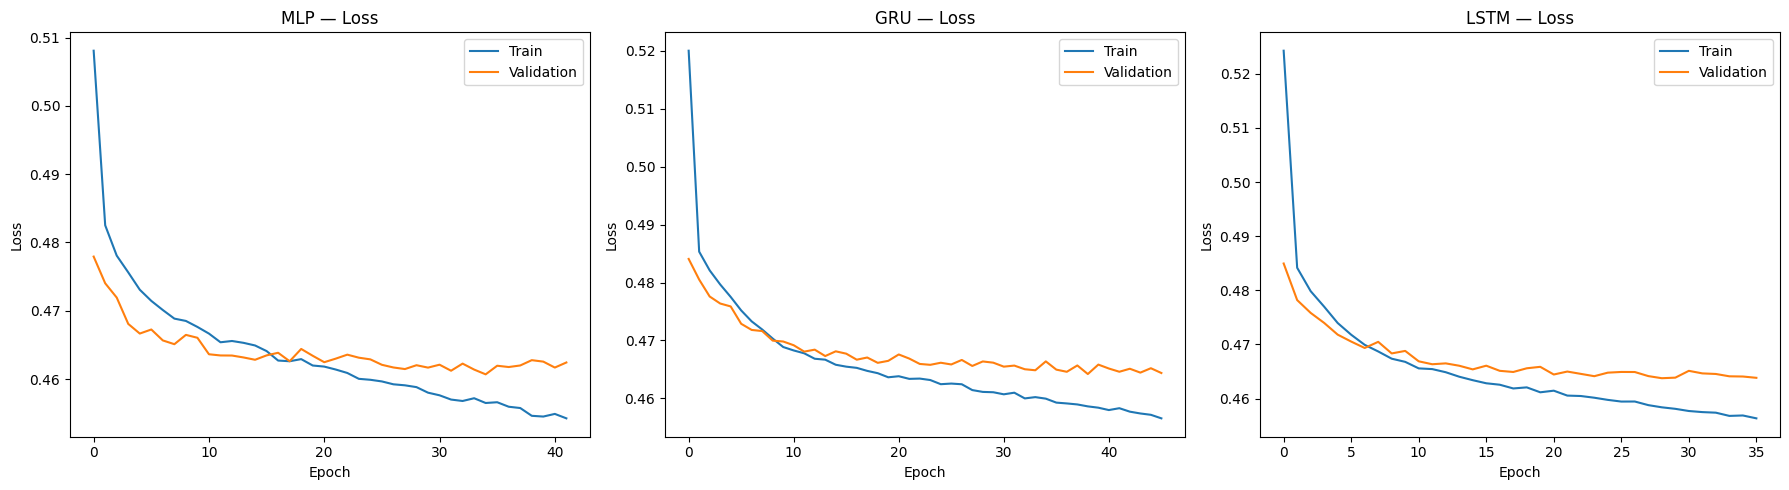

In [17]:
# Training curves for PyTorch models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, r) in zip(axes, [(n, results[n]) for n in ["MLP", "GRU", "LSTM"]]):
    h = r["history"]
    ax.plot(h["train_loss"], label="Train")
    ax.plot(h["val_loss"], label="Validation")
    ax.set_title(f"{name} — Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()

plt.tight_layout()
plt.show()

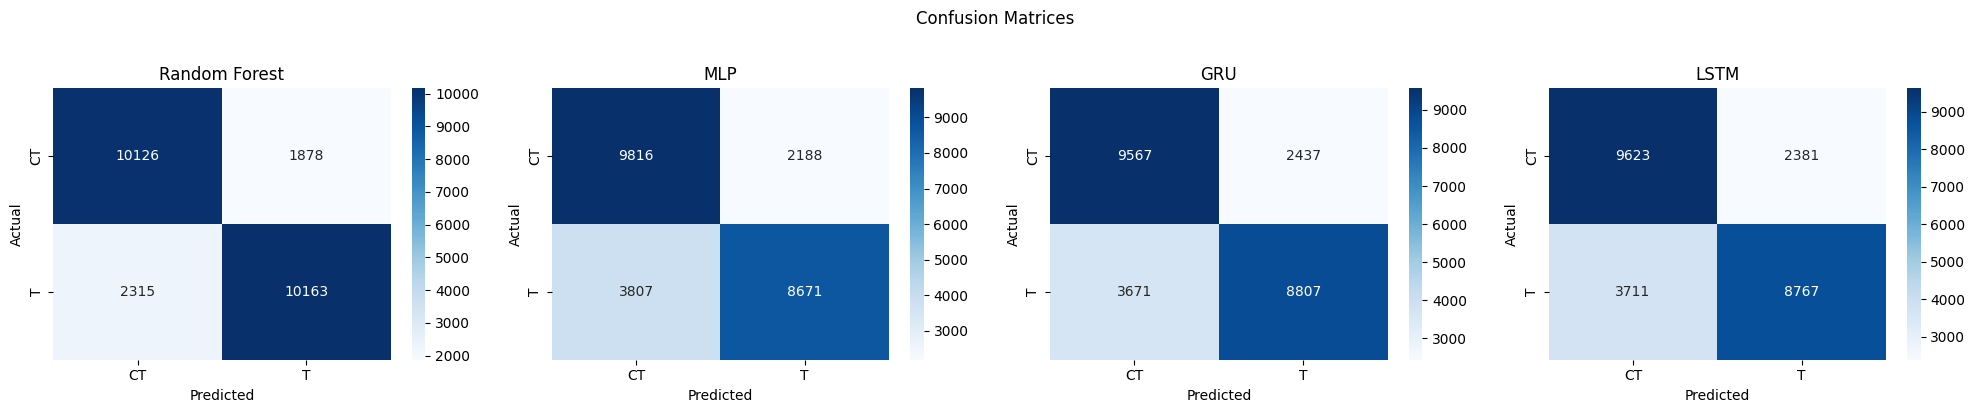

In [18]:
# Confusion matrices
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
y_true = y_test.values

for ax, (name, r) in zip(axes, results.items()):
    preds = (r["probs"] > 0.5).astype(int)
    cm = confusion_matrix(y_true, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["CT", "T"], yticklabels=["CT", "T"])
    ax.set_title(f"{name}")
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

plt.suptitle("Confusion Matrices", y=1.02)
plt.tight_layout()
plt.show()

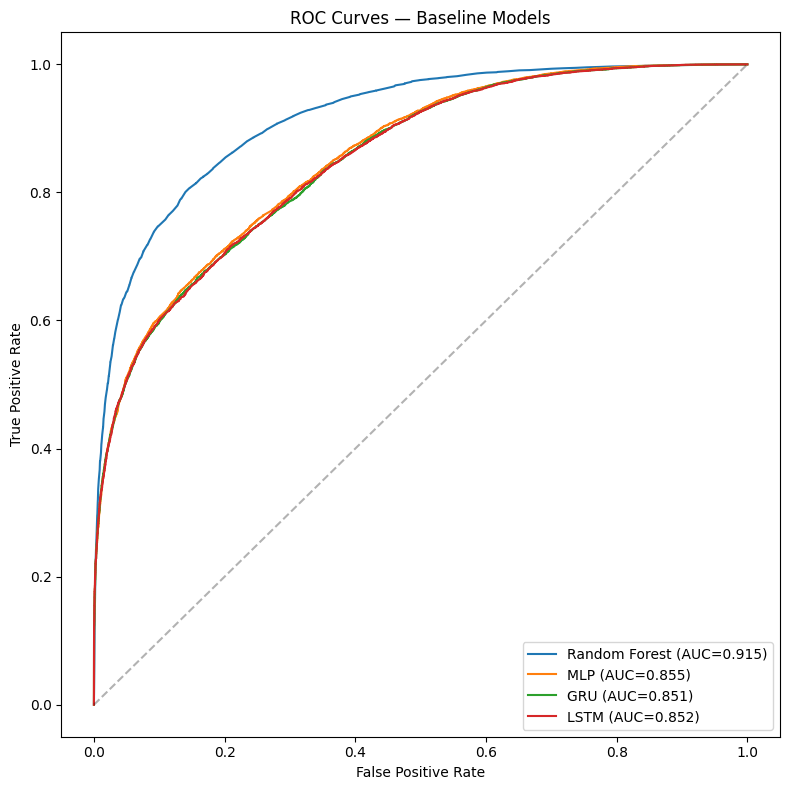

In [19]:
# ROC curves
fig, ax = plt.subplots(figsize=(8, 8))

for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_true, r["probs"])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Baseline Models")
ax.legend()
plt.tight_layout()
plt.show()

## Save Baseline Models

In [22]:
import joblib

# save sklearn models
joblib.dump(rf, MODEL_DIR / "rf_baseline.joblib")
joblib.dump(scaler, MODEL_DIR / "scaler.joblib")

# save PyTorch models
torch.save(mlp.state_dict(), MODEL_DIR / "mlp_baseline.pt")
torch.save(gru.state_dict(), MODEL_DIR / "gru_baseline.pt")
torch.save(lstm.state_dict(), MODEL_DIR / "lstm_baseline.pt")

# save results for later comparison
baseline_results = {name: r["acc"] for name, r in results.items()}
json.dumps(baseline_results)
(DATA_DIR / "baseline_results.json").write_text(json.dumps(baseline_results, indent=2))

print("done")

done
